In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Ignore all FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


df = pd.read_csv('../EDA/train_clean.csv')
df

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,49.0,Ludhiana,Working Professional,Chef,0,5,0.00,0,2,> 8 hours,Healthy,BHM,No,1,2,No,0
1,Male,26.0,Varanasi,Working Professional,Teacher,0,4,0.00,0,3,< 5 hours,Unhealthy,LLB,Yes,7,3,No,1
2,Male,33.0,Visakhapatnam,Student,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1,No,1
3,Male,22.0,Mumbai,Working Professional,Teacher,0,5,0.00,0,1,< 5 hours,Moderate,BBA,Yes,10,1,Yes,1
4,Female,30.0,Kanpur,Working Professional,Business Analyst,0,1,0.00,0,1,5-6 hours,Unhealthy,BBA,Yes,9,4,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,Female,18.0,Ahmedabad,Working Professional,Unemployed,0,5,0.00,0,4,5-6 hours,Unhealthy,Class 12,No,2,4,Yes,1
140696,Female,41.0,Hyderabad,Working Professional,Content Writer,0,5,0.00,0,4,7-8 hours,Moderate,B.Tech,Yes,6,5,Yes,0
140697,Female,24.0,Kolkata,Working Professional,Marketing Manager,0,3,0.00,0,1,> 8 hours,Moderate,B.Com,No,4,4,No,0
140698,Female,49.0,Srinagar,Working Professional,Plumber,0,5,0.00,0,2,5-6 hours,Moderate,ME,Yes,10,1,No,0


## Mutual Information

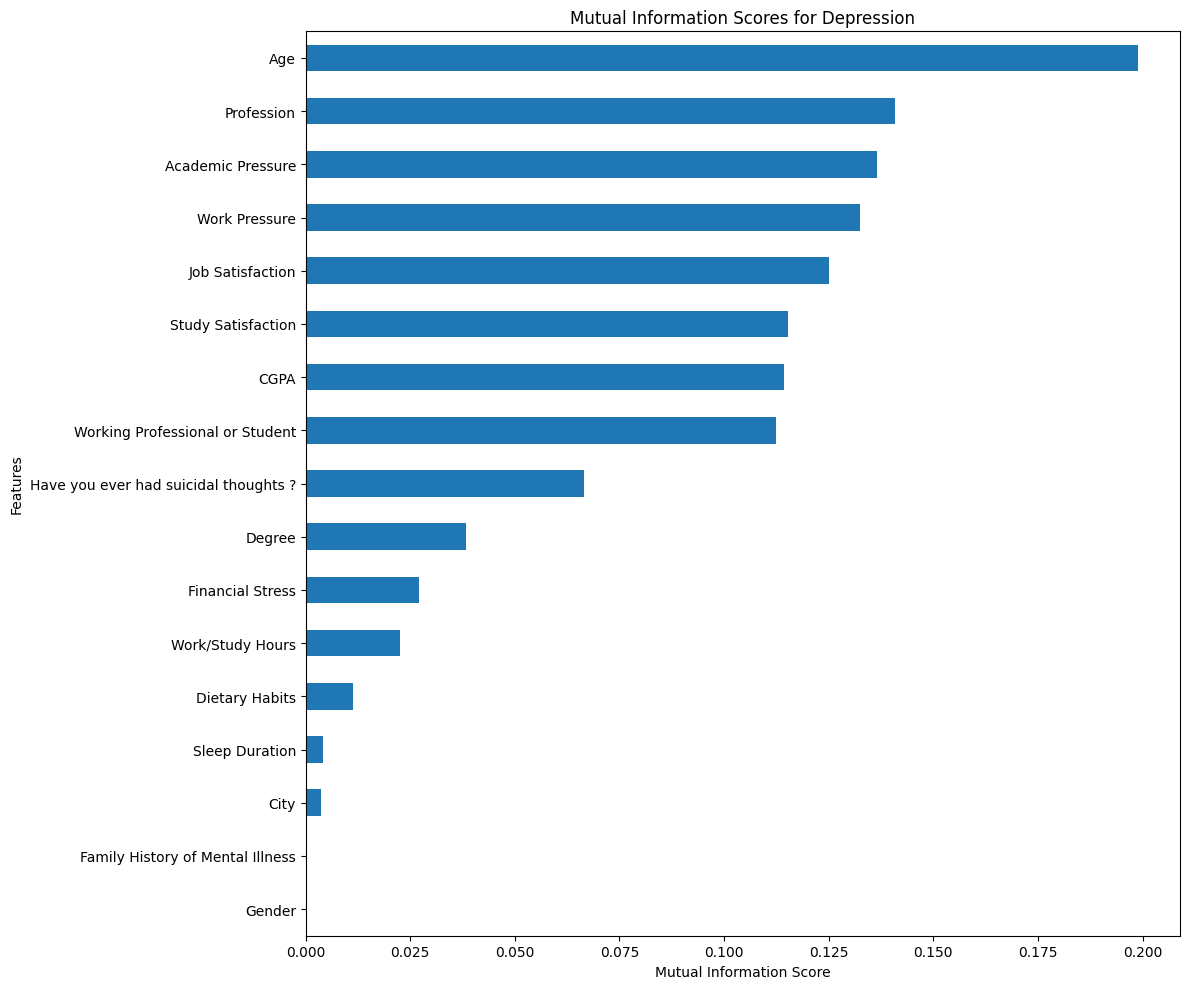

In [20]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
# Separate features and target
X = df.drop(columns=['Depression'])
y = df['Depression']

# Label Encode categorical columns instead of One-Hot
X_le = X.copy()
label_encoders = {}
for col in X_le.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    X_le[col] = le.fit_transform(X_le[col].astype(str))
    label_encoders[col] = le

# Compute Mutual Information
mi_scores = mutual_info_classif(X_le, y, discrete_features=True)

# Convert to Series and sort from largest to smallest
mi_scores = pd.Series(mi_scores, index=X_le.columns).sort_values(ascending=False)

# Plot ALL features, sorted
plt.figure(figsize=(12, 10))
mi_scores.plot(kind='barh')
plt.title("Mutual Information Scores for Depression")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # highest score at the top
plt.tight_layout()
plt.show()


## Correlation

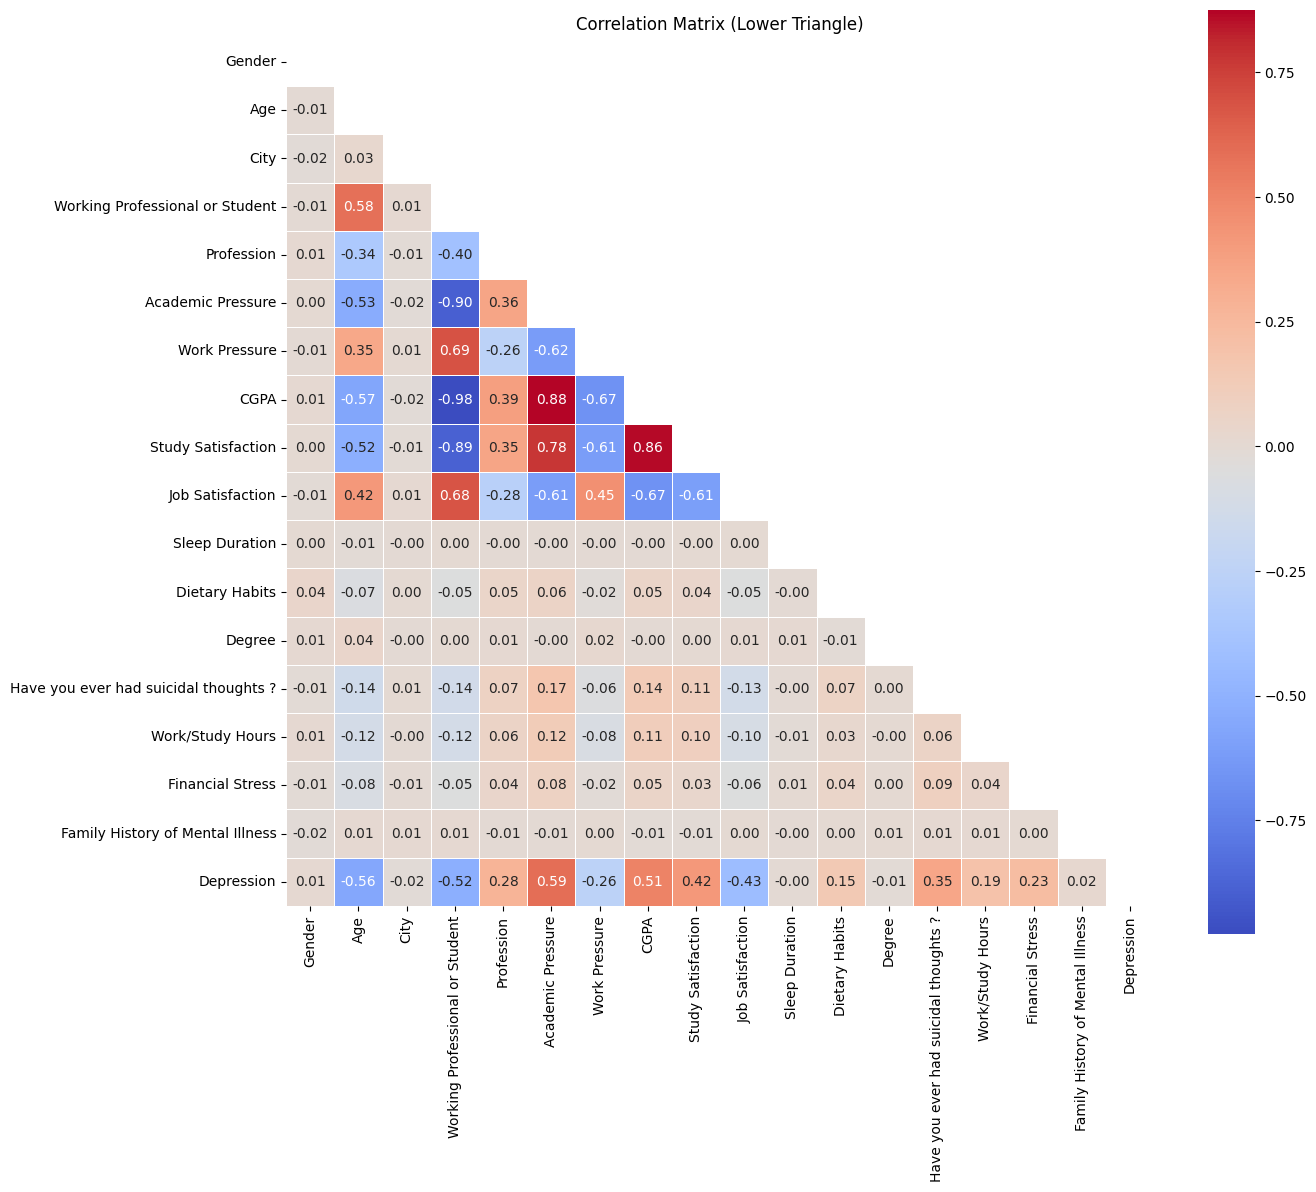

In [21]:
# Encode categorical columns
df_corr = df.copy()
for col in df_corr.select_dtypes(include=['object', 'category']).columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=True, fmt=".2f", square=True, linewidths=.5)
plt.title("Correlation Matrix (Lower Triangle)")
plt.show()


## EDA

In [22]:
sleep_categories = ['< 5 hours', '5-6 hours', '7-8 hours', '> 8 hours']
df['Sleep Duration'] = pd.Categorical(df['Sleep Duration'], categories=sleep_categories, ordered=True)
habit_categories = ['Unhealthy','Moderate','Healthy']
df['Dietary Habits'] = pd.Categorical(df['Dietary Habits'], categories=habit_categories, ordered=True)
df.dtypes

Gender                                     object
Age                                       float64
City                                       object
Working Professional or Student            object
Profession                                 object
Academic Pressure                           int64
Work Pressure                               int64
CGPA                                      float64
Study Satisfaction                          int64
Job Satisfaction                            int64
Sleep Duration                           category
Dietary Habits                           category
Degree                                     object
Have you ever had suicidal thoughts ?      object
Work/Study Hours                            int64
Financial Stress                            int64
Family History of Mental Illness           object
Depression                                  int64
dtype: object

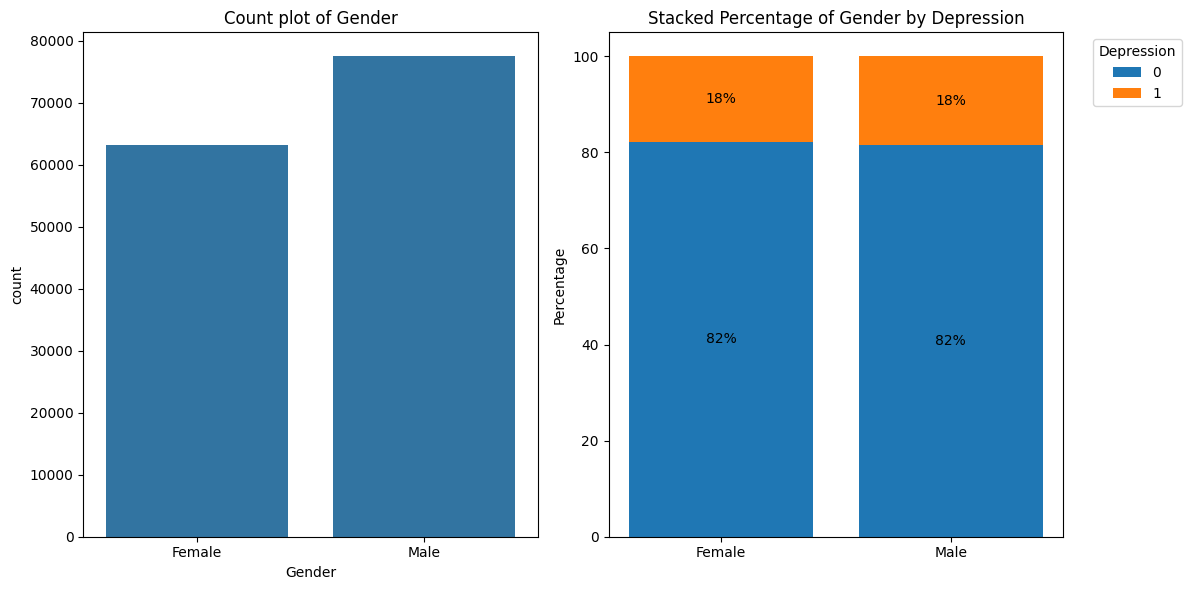

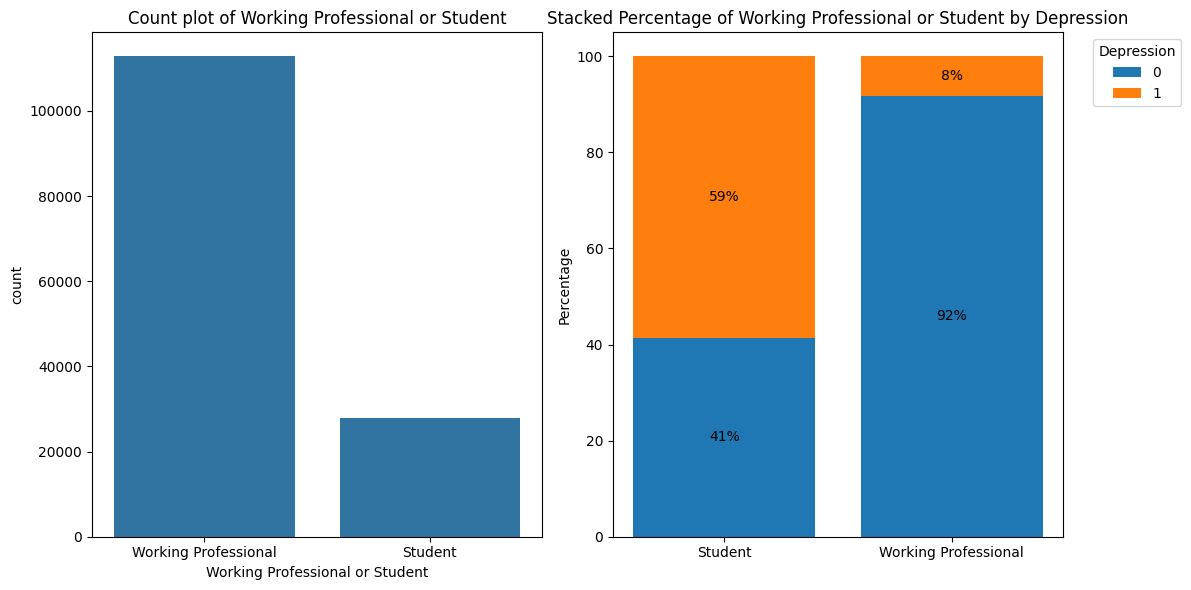

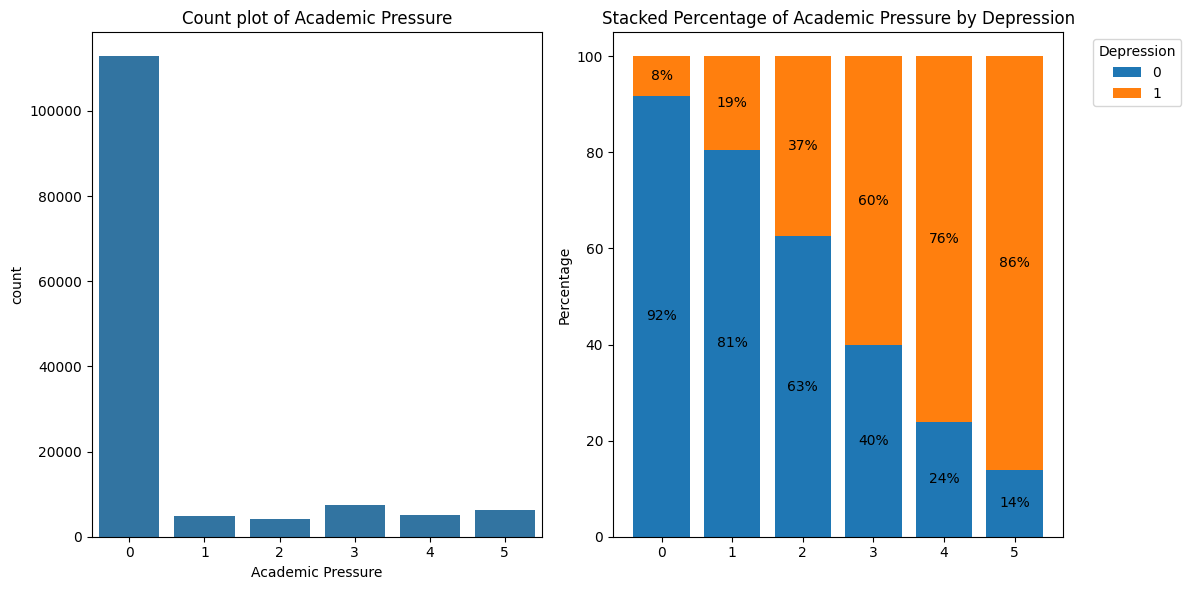

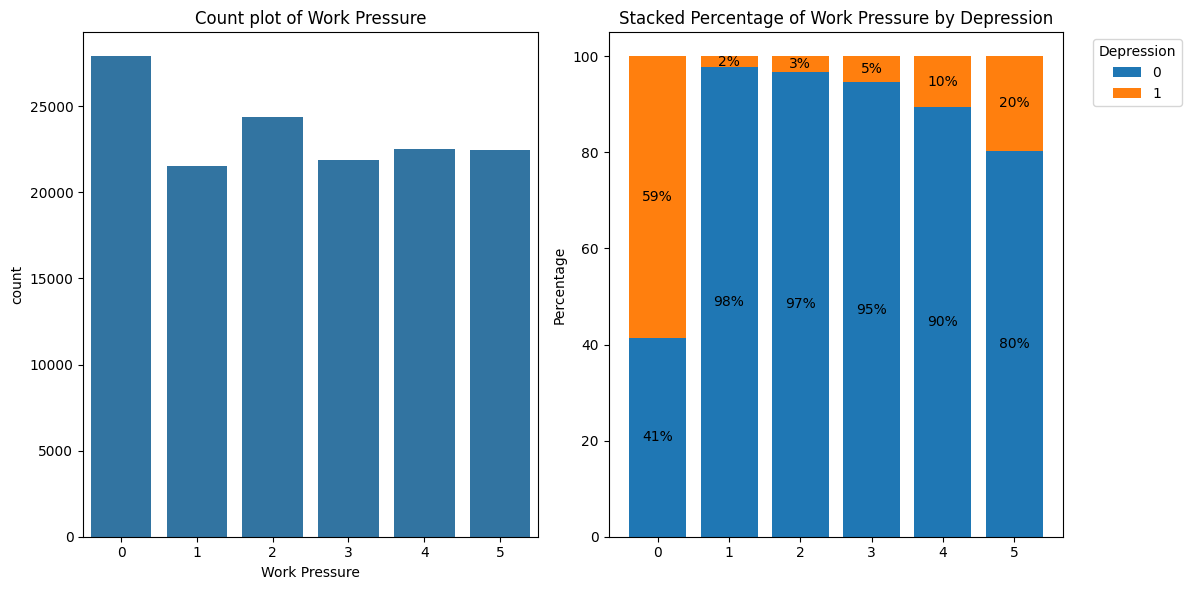

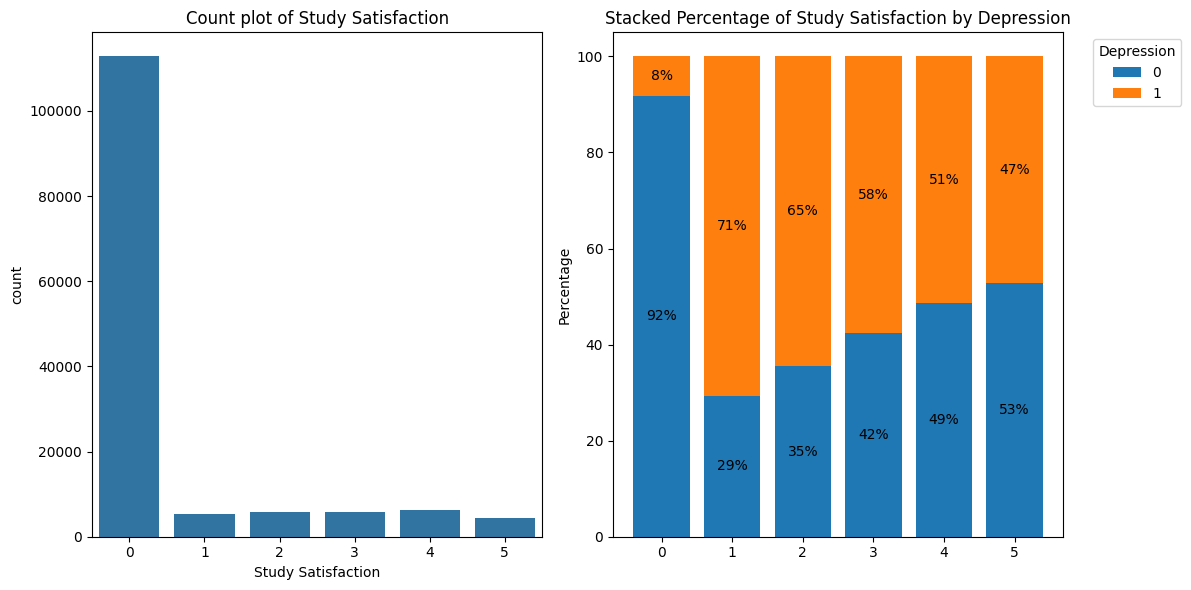

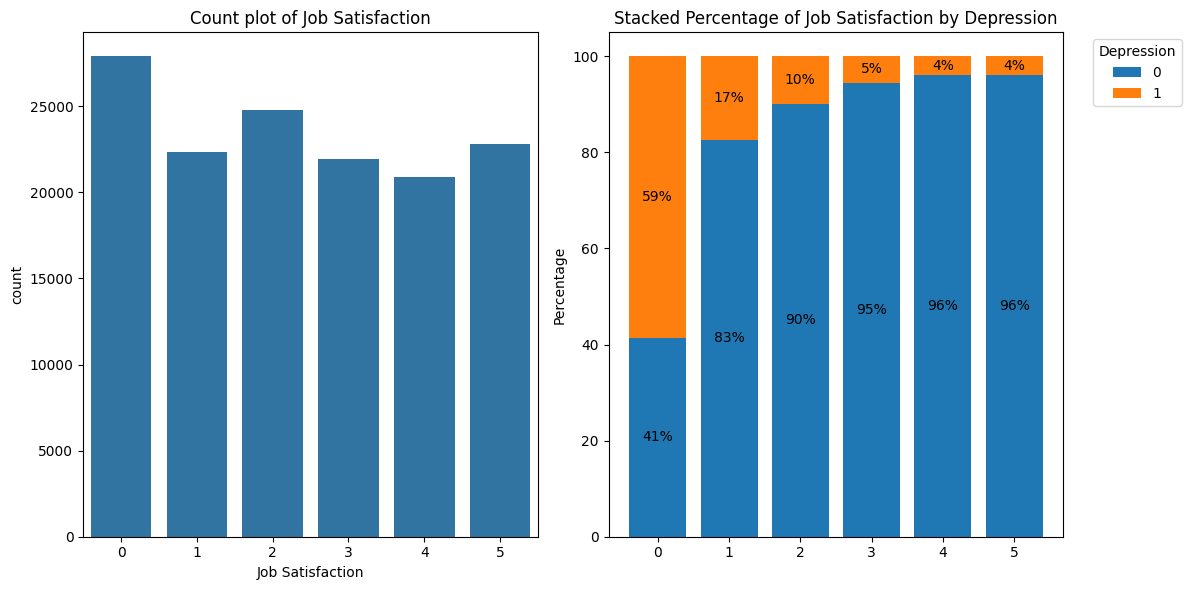

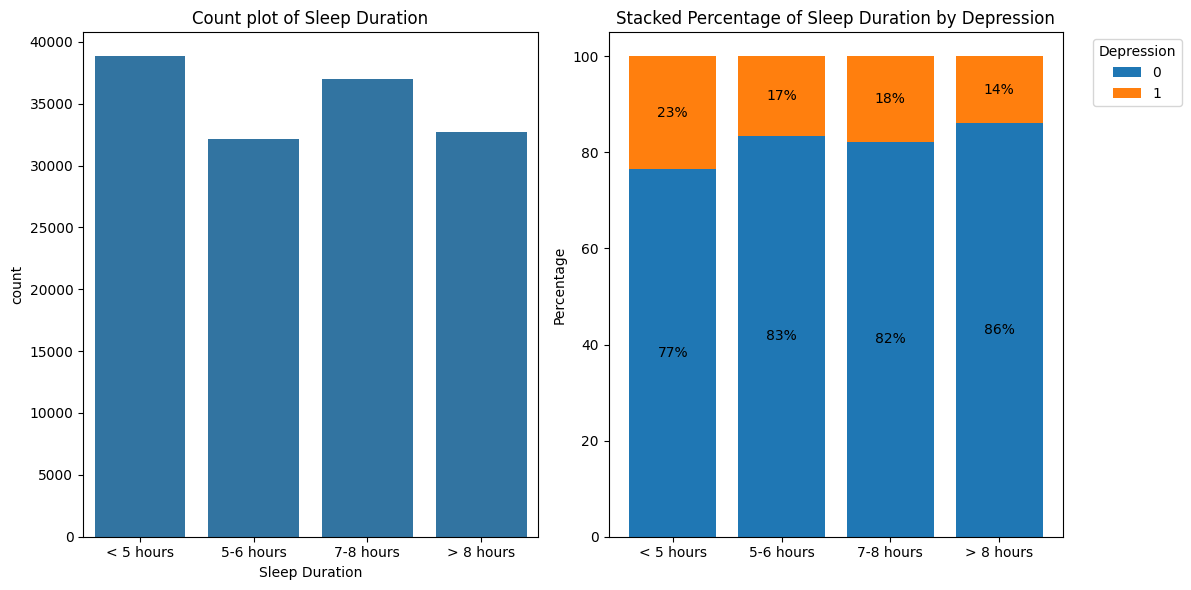

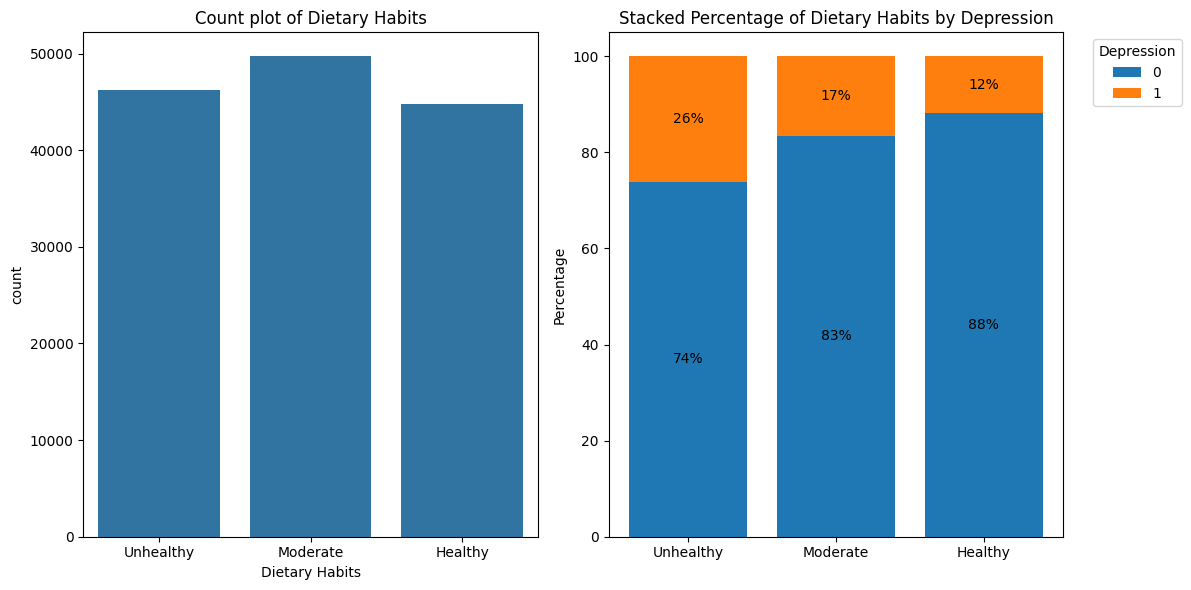

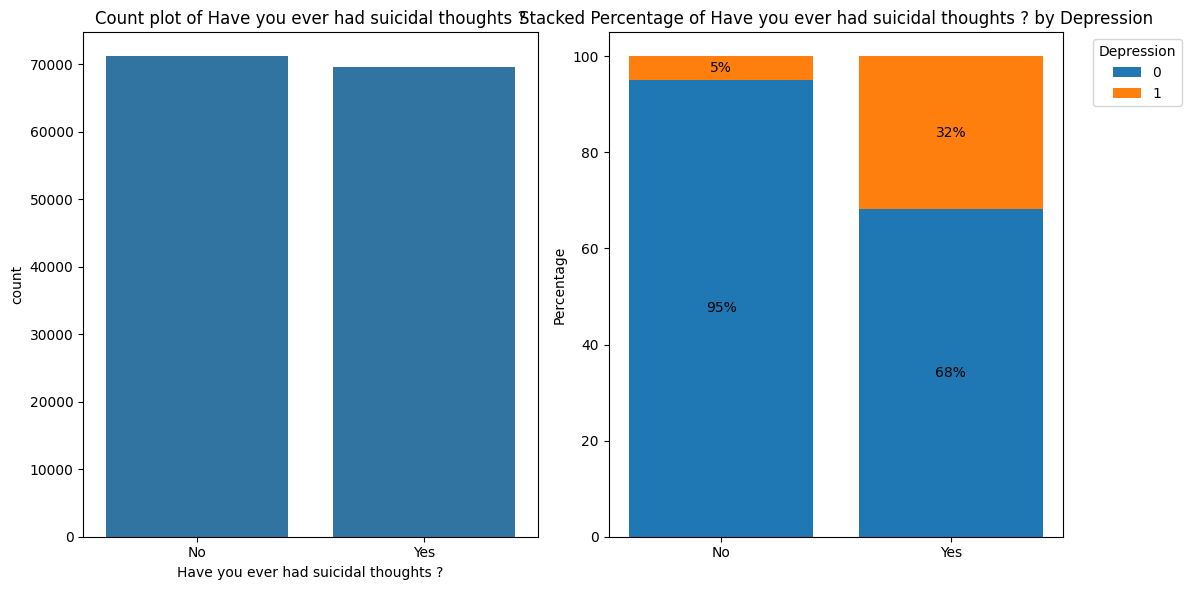

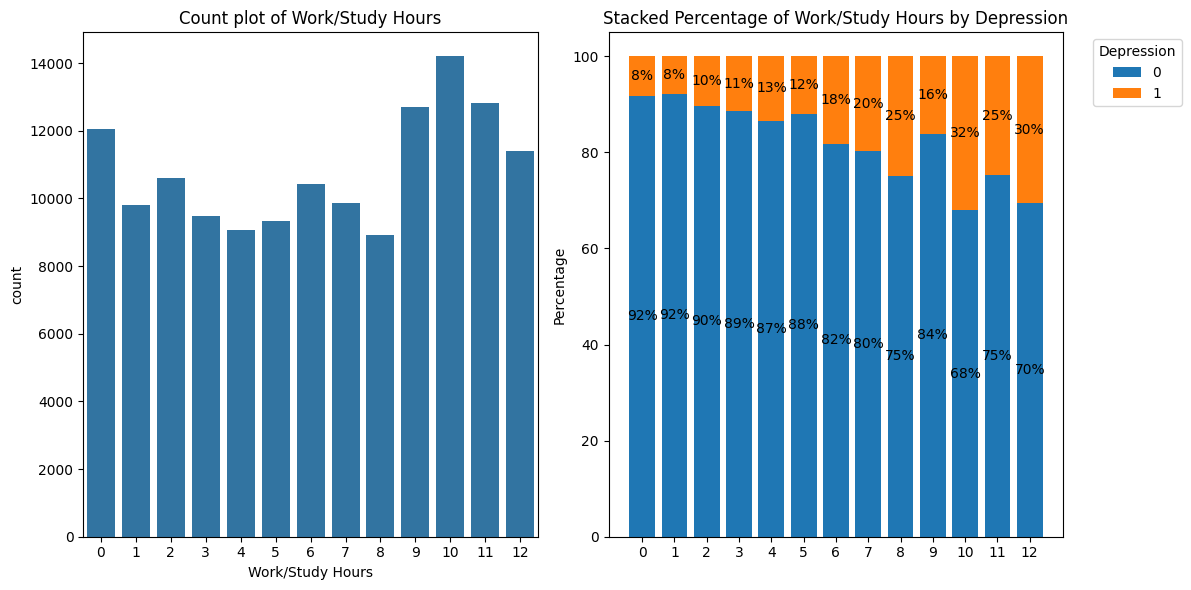

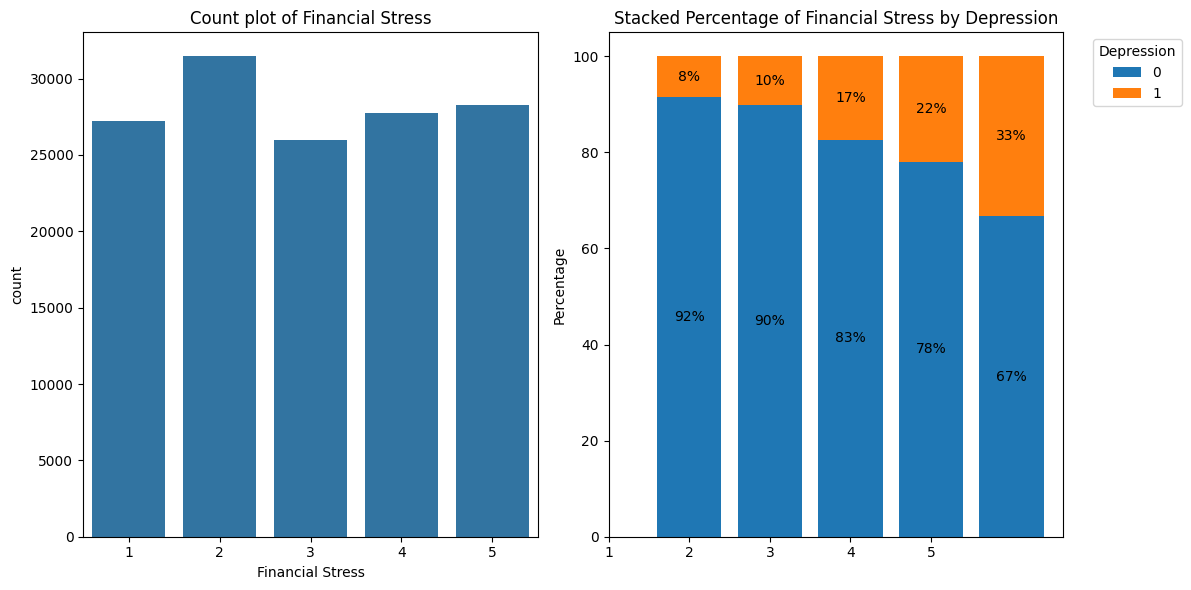

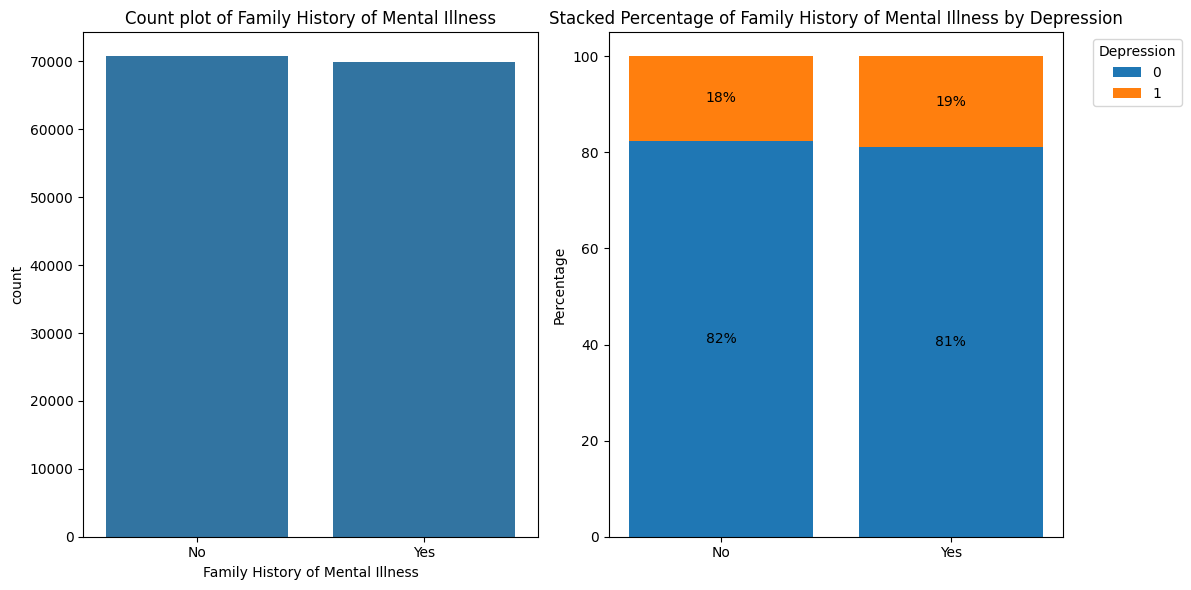

In [24]:
def plot_cat_vs_target(df, target, max_unique=20):
    for col in df.columns:
        if col == target:
            continue
        if df[col].nunique() <= max_unique:
            fig, ax = plt.subplots(1, 2, figsize=(12, 6))
            sns.countplot(x=col, data=df, ax=ax[0])
            ax[0].set_title(f"Count plot of {col}")
            
            crosstab = pd.crosstab(df[col], df[target], normalize='index') * 100
            bottom = pd.Series(0, index=crosstab.index)
            
            for category in crosstab.columns:
                ax[1].bar(crosstab.index, crosstab[category], bottom=bottom, label=f"{category}")
                for idx, value in enumerate(crosstab[category]):
                    if value > 0:
                        ax[1].text(crosstab.index[idx], bottom.iloc[idx] + value / 2, f"{value:.0f}%", ha='center', va='center')
                bottom += crosstab[category].values
            
            ax[1].set_title(f"Stacked Percentage of {col} by {target}")
            ax[1].set_ylabel("Percentage")
            ax[1].legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
            ax[1].set_xticks(range(len(crosstab.index)))
            ax[1].set_xticklabels(crosstab.index)
            plt.tight_layout()
            plt.show()
            
plot_cat_vs_target(df, target='Depression')

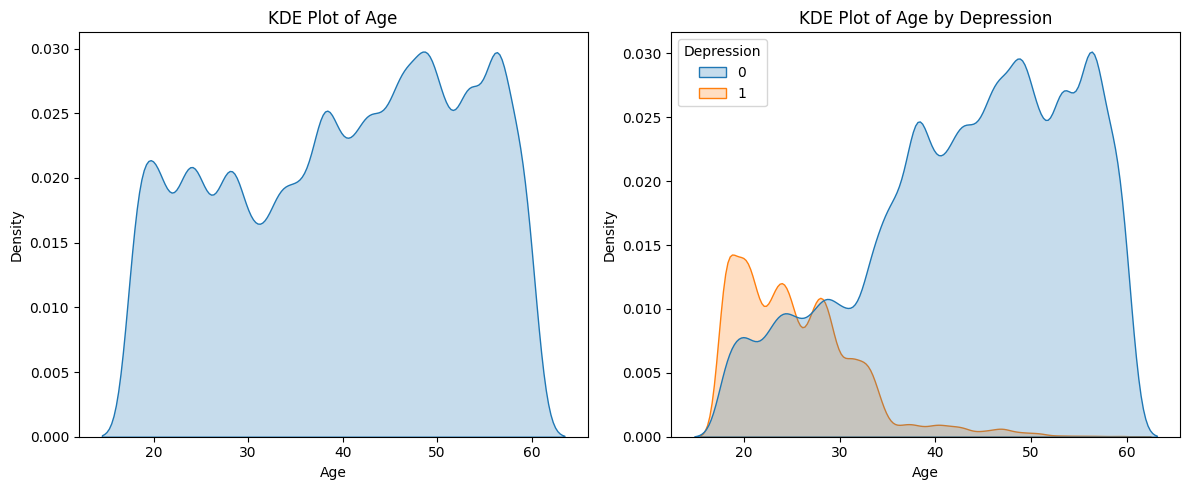

In [25]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot 1: KDE plot for Age
sns.kdeplot(data=df, x='Age', ax=axes[0],fill=True)
axes[0].set_title('KDE Plot of Age')

# Plot 2: KDE plot for Age with hue='Depression'
sns.kdeplot(data=df, x='Age', hue='Depression', ax=axes[1],fill=True)
axes[1].set_title('KDE Plot of Age by Depression')

# Adjust layout for clarity
plt.tight_layout()
plt.show()

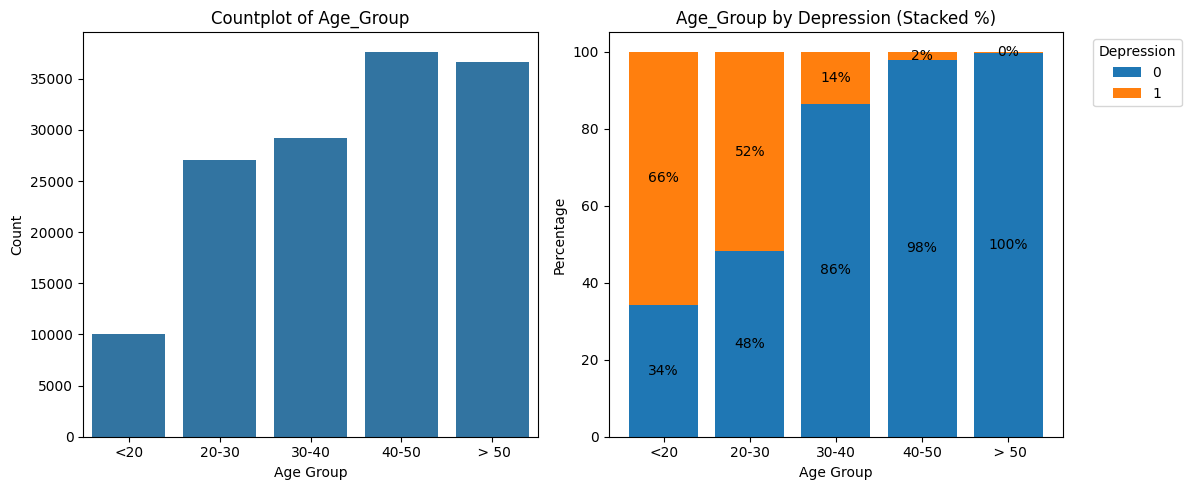

In [26]:
def age_group(df, age_column='Age'):
    bins = [0, 20, 30, 40, 50, np.inf]  # Age bins
    labels = ['<20', '20-30', '30-40', '40-50', ' > 50']  # Labels
    
    df['Age_Group'] = pd.cut(
        df[age_column], 
        bins=bins, 
        labels=labels, 
        right=True, 
        include_lowest=True
    )
    
    df['Age_Group'] = pd.Categorical(df['Age_Group'], categories=labels, ordered=True)
    
    return df

age_group(df)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Countplot for Age_Group
sns.countplot(data=df, x='Age_Group', ax=ax[0])
ax[0].set_title('Countplot of Age_Group')
# ax[0].tick_params(axis='x', rotation=90)
ax[0].set_xlabel('Age Group')
ax[0].set_ylabel('Count')

# Prepare data for the stacked percentage plot
crosstab = pd.crosstab(df['Age_Group'], df['Depression'], normalize='index') * 100  # Normalize to percentages
bottom = pd.Series(0, index=crosstab.index)  # Initialize bottom tracker for stacking

# Plot 2: Stacked percentage bar plot
for category in crosstab.columns:
    ax[1].bar(crosstab.index, crosstab[category], bottom=bottom, label=f"{category}")
    # Add percentage annotations
    for idx, value in enumerate(crosstab[category]):
        if value > 0:  # Annotate only non-zero percentages
            ax[1].text(idx, bottom[idx] + value / 2, f"{value:.0f}%", ha='center', va='center')
    bottom += crosstab[category]  # Update the bottom for the next segment

# Set title, labels, and legend for the second plot
ax[1].set_title('Age_Group by Depression (Stacked %)')
ax[1].set_xlabel('Age Group')
ax[1].set_ylabel('Percentage')
ax[1].legend(title='Depression', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax[1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()


<Axes: xlabel='Age_Risk', ylabel='count'>

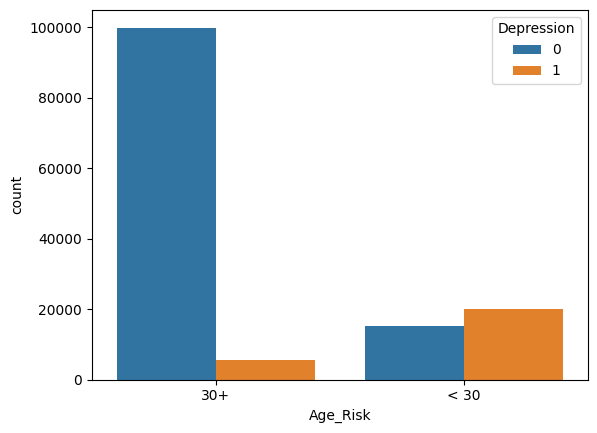

In [27]:
df['Age_Risk'] = df['Age'].apply(lambda x: '< 30' if x < 30 else '30+')
sns.countplot(x='Age_Risk',data=df,hue='Depression')

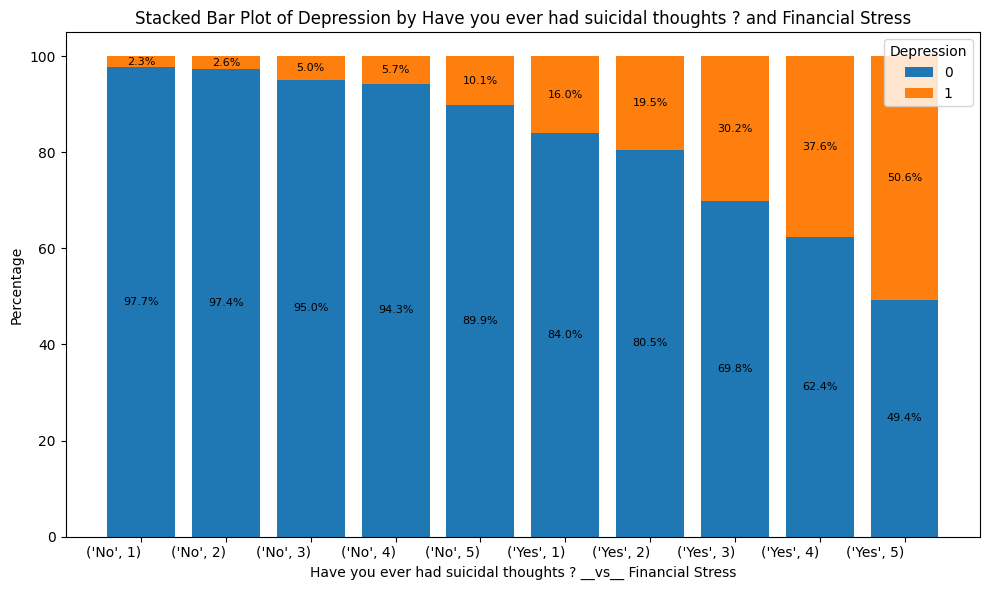

In [28]:
def EDA_stacked_depression(df, col_1, col_2, target='Depression'):
    grouped_data = df.groupby([col_1, col_2])[target] \
                     .value_counts(normalize=True).mul(100) \
                     .to_frame('Percentage').reset_index()
    
    pivot_data = grouped_data.pivot_table(
        index=[col_1, col_2], 
        columns=target, 
        values='Percentage', 
        fill_value=0
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bottom_values = pd.Series(0, index=pivot_data.index)
    
    for depression_level in pivot_data.columns:
        bars = ax.bar(
            range(len(pivot_data.index)), 
            pivot_data[depression_level],
            bottom=bottom_values, 
            label=depression_level
        )
        
        for bar, (_, row) in zip(bars, pivot_data.iterrows()):
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f'{height:.1f}%',
                    ha='center', va='center', fontsize=8
                )
        bottom_values += pivot_data[depression_level]
    
    ax.set_title(f'Stacked Bar Plot of {target} by {col_1} and {col_2}')
    ax.set_ylabel('Percentage')
    ax.set_xlabel(f'{col_1} __vs__ {col_2}')
    ax.legend(title=target)
    plt.xticks(range(len(pivot_data.index)), pivot_data.index, ha='right')
    plt.tight_layout()
    plt.show()

EDA_stacked_depression(df, 'Have you ever had suicidal thoughts ?', 'Financial Stress', target='Depression')

In [29]:
def categorize_risk(df):
    df['Risk_Level'] = df.apply(
        lambda row: 'High Risk' if row['Have you ever had suicidal thoughts ?'] == 'Yes' and row['Financial Stress'] >= 4 else 'Low Risk',
        axis=1)
    return df

categorize_risk(df)

,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,...,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Age_Group,Age_Risk,Risk_Level
0,Female,49.0,Ludhiana,Working Professional,Chef,0,5,0.00,0,2,...,Healthy,BHM,No,1,2,No,0,40-50,30+,Low Risk
1,Male,26.0,Varanasi,Working Professional,Teacher,0,4,0.00,0,3,...,Unhealthy,LLB,Yes,7,3,No,1,20-30,< 30,Low Risk
2,Male,33.0,Visakhapatnam,Student,Student,5,0,8.97,2,0,...,Healthy,B.Pharm,Yes,3,1,No,1,30-40,30+,Low Risk
3,Male,22.0,Mumbai,Working Professional,Teacher,0,5,0.00,0,1,...,Moderate,BBA,Yes,10,1,Yes,1,20-30,< 30,Low Risk
4,Female,30.0,Kanpur,Working Professional,Business Analyst,0,1,0.00,0,1,...,Unhealthy,BBA,Yes,9,4,Yes,0,20-30,30+,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140695,Female,18.0,Ahmedabad,Working Professional,Unemployed,0,5,0.00,0,4,...,Unhealthy,Class 12,No,2,4,Yes,1,<20,< 30,Low Risk
140696,Female,41.0,Hyderabad,Working Professional,Content Writer,0,5,0.00,0,4,...,Moderate,B.Tech,Yes,6,5,Yes,0,40-50,30+,High Risk
140697,Female,24.0,Kolkata,Working Professional,Marketing Manager,0,3,0.00,0,1,...,Moderate,B.Com,No,4,4,No,0,20-30,< 30,Low Risk
140698,Female,49.0,Srinagar,Working Professional,Plumber,0,5,0.00,0,2,...,Moderate,ME,Yes,10,1,No,0,40-50,30+,Low Risk


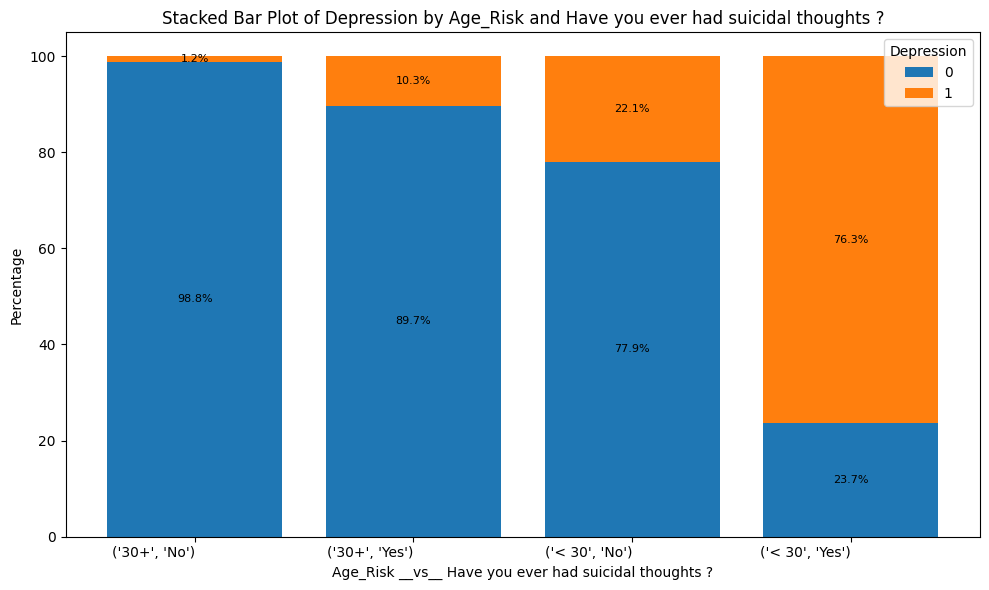

In [30]:
EDA_stacked_depression(df, 'Age_Risk','Have you ever had suicidal thoughts ?', target='Depression')

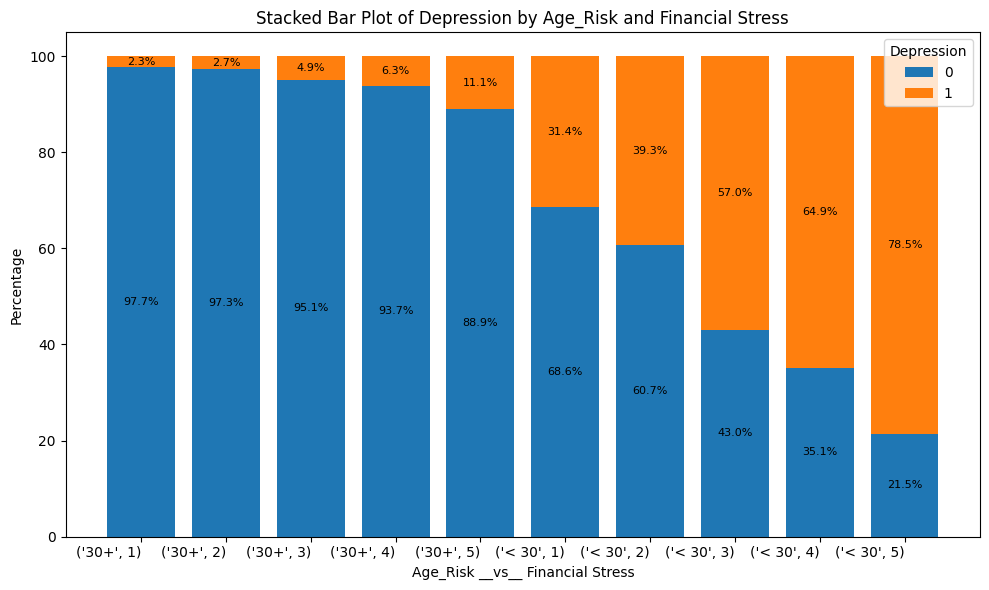

In [31]:
EDA_stacked_depression(df, 'Age_Risk','Financial Stress', target='Depression')

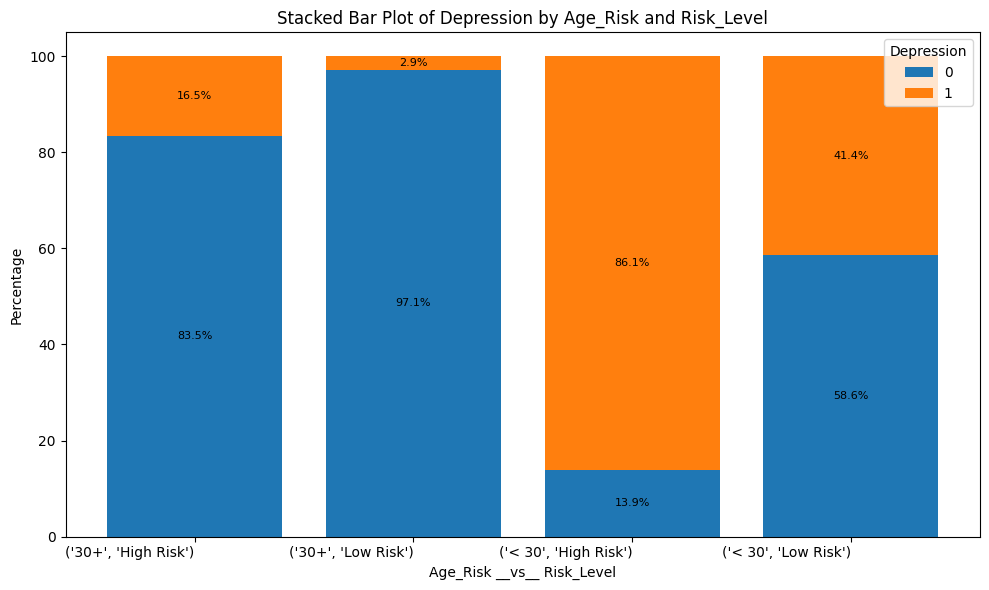

In [32]:
EDA_stacked_depression(df, 'Age_Risk','Risk_Level', target='Depression')

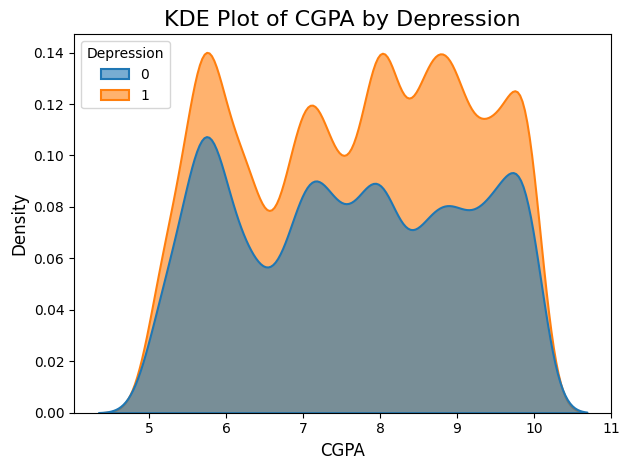

In [33]:
sns.kdeplot(
    x='CGPA',
    data=df[df['CGPA'] != 0],
    fill=True,
    hue='Depression',
    alpha=0.6,  # Adjust transparency
    linewidth=1.5  # Line thickness for better visibility
)

# Add title and labels
plt.title('KDE Plot of CGPA by Depression', fontsize=16)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Show plot
plt.tight_layout()
plt.show()

<Axes: xlabel='Depression', ylabel='count'>

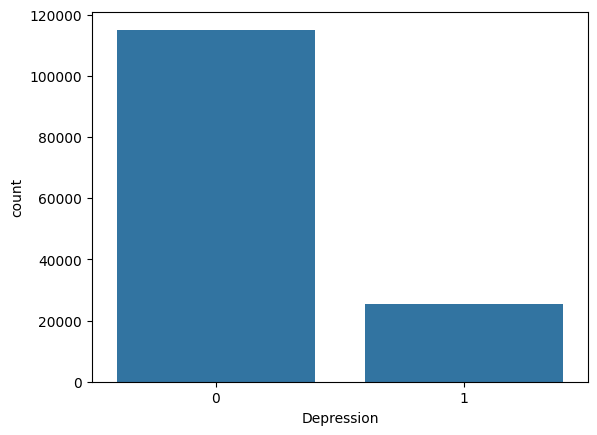

In [34]:
sns.countplot(x='Depression',data=df)

In [ ]:
df.to_csv('../EDA/train_dataset_final.csv',index=False)